# 02 - Análisis exploratorio: caracterización de la base de clientes

El notebook 00 preguntaba *"¿los datos están sucios? ¿se pueden confiar?"* (diagnóstico de
calidad). Este notebook pregunta algo distinto: *"ahora que los datos están limpios e
integrados en `Cliente 360`, qué me dicen sobre mis clientes y sobre la oportunidad de
negocio"*.

Aquí sí usamos gráficas (en el notebook 00 solo usamos tablas de números), porque el
objetivo de este notebook es entender y comunicar patrones, no solo detectar errores.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
pd.options.display.float_format = '{:,.2f}'.format

cliente_360 = pd.read_csv('../04_Resultados/cliente_360.csv')
print('Clientes:', len(cliente_360))
cliente_360.head()

Clientes: 859796


,numero_id,grupo_edad,desc_genero,desc_segmento,desc_tipo_de_vivienda,ingresos_mensuales,total_egresos_mensuales,total_activos,total_pasivos,total_patrimonio,...,tiene_aho_cte,saldo_bolsillos,tiene_bolsillos,saldo_fiducuenta,tiene_fiducuenta,saldo_cdt_inv_virtual,tiene_cdt_inv_virtual,saldo_invesbot,tiene_invesbot,estimador_ingreso
0,8805210490649048784,65+,masculino,preferencial,NO INFORMA,"29,239,444.00","30,000,000.00","145,047,043,000.00","6,356,702,000.00","105,422,323.00",...,False,0.00,False,0.00,False,0.00,False,0.00,False,NaN
1,-5723572980375902369,50-65,masculino,preferencial,PROPIA,"31,024,544.00","10,000,000.00","1,133,345,000.00","83,072,000.00","1,050,273,000.00",...,False,0.00,False,0.00,False,0.00,False,0.00,False,NaN
2,-8245474570363424359,65+,masculino,preferencial,PROPIA,"2,834,000.00","500,000.00","1,073,787,017.00",0.00,"343,000,000.00",...,False,0.00,False,0.00,False,"450,267,852.65",True,0.00,False,NaN
3,-7840506796880772723,65+,femenino,preferencial,PROPIA,"28,035,850.00",0.00,"175,000,000.00",0.00,"55,000,000.00",...,False,0.00,False,0.00,False,0.00,False,0.00,False,NaN
4,5309731180094827430,36-49,femenino,preferencial,FAMILIAR,"3,846,205.00","2,500,000.00","758,000,000.00",0.00,"758,000,000.00",...,False,0.00,False,0.00,False,0.00,False,0.00,False,NaN


## 1. Panorama general

Antes de entrar en detalle, un vistazo rápido: cuántos clientes hay, y con qué variables
contamos para caracterizarlos.

In [2]:
cliente_360.info()

<class 'pandas.DataFrame'>
RangeIndex: 859796 entries, 0 to 859795
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   numero_id                859796 non-null  int64  
 1   grupo_edad               859796 non-null  str    
 2   desc_genero              859796 non-null  str    
 3   desc_segmento            859796 non-null  str    
 4   desc_tipo_de_vivienda    859796 non-null  str    
 5   ingresos_mensuales       859796 non-null  float64
 6   total_egresos_mensuales  859796 non-null  float64
 7   total_activos            859796 non-null  float64
 8   total_pasivos            859796 non-null  float64
 9   total_patrimonio         859796 non-null  float64
 10  saldo_aho_cte            859796 non-null  float64
 11  tiene_aho_cte            859796 non-null  bool   
 12  saldo_bolsillos          859796 non-null  float64
 13  tiene_bolsillos          859796 non-null  bool   
 14  saldo_fiducuent

## 2. ¿Cómo se distribuye la base por edad, género, segmento y vivienda?

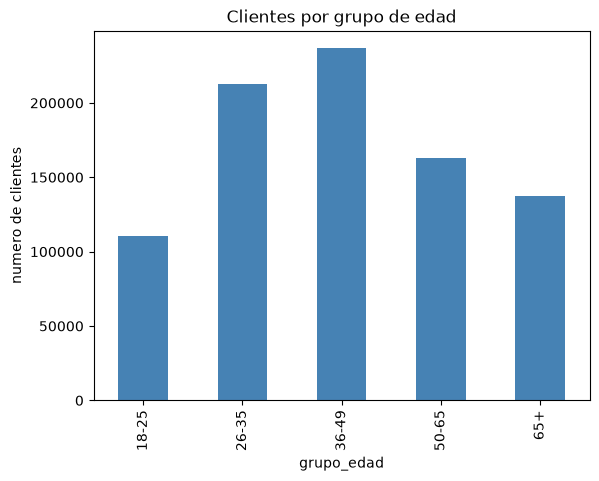

In [3]:
cliente_360['grupo_edad'].value_counts().sort_index().plot(
    kind='bar', title='Clientes por grupo de edad', color='steelblue'
)
plt.ylabel('numero de clientes')
plt.show()

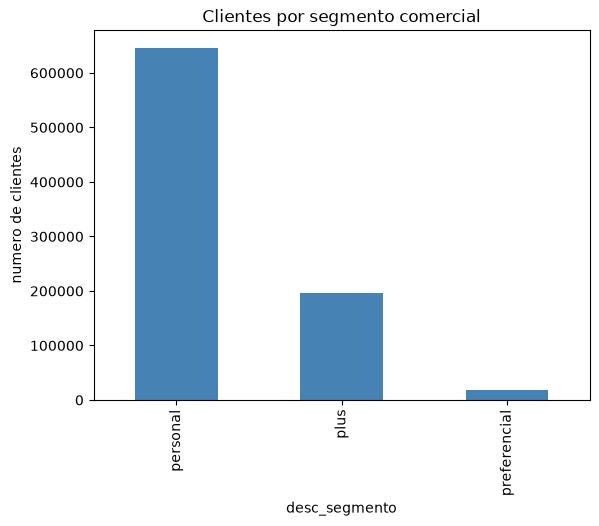

In [4]:
cliente_360['desc_segmento'].value_counts().plot(
    kind='bar', title='Clientes por segmento comercial', color='steelblue'
)
plt.ylabel('numero de clientes')
plt.show()

desc_genero
femenino      472395
masculino     387230
no informa        93
no binario        45
trans             33
Name: count, dtype: int64


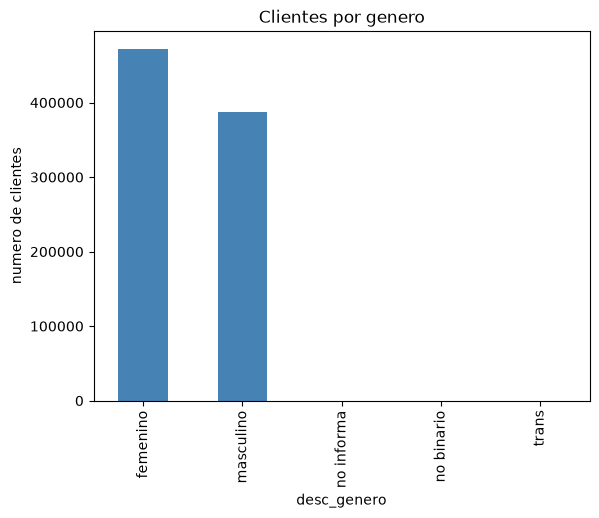

In [5]:
print(cliente_360['desc_genero'].value_counts())

cliente_360['desc_genero'].value_counts().plot(
    kind='bar', title='Clientes por genero', color='steelblue'
)
plt.ylabel('numero de clientes')
plt.show()

**Nota:** `no informa`, `no binario` y `trans` casi no se ven en la gráfica — no es un
error, es que son grupos muy pequeños (93, 45 y 33 clientes) comparados con femenino y
masculino (cientos de miles cada uno). En una gráfica de barras normal, una diferencia
así de grande hace que las barras chiquitas casi no tengan altura visible. Por eso se
imprime la tabla con los números exactos justo antes del gráfico.

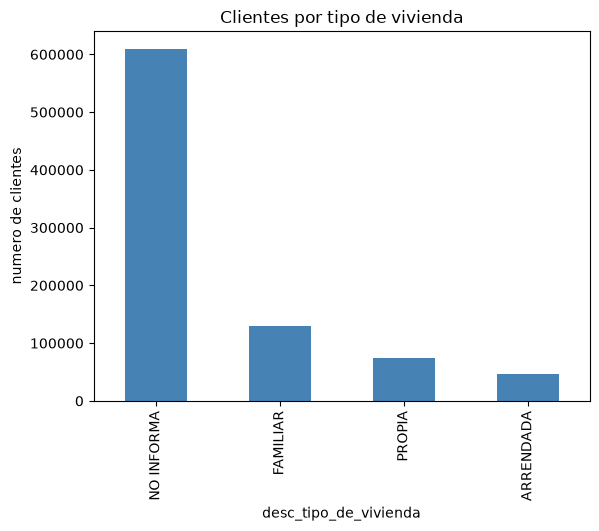

In [6]:
cliente_360['desc_tipo_de_vivienda'].value_counts().plot(
    kind='bar', title='Clientes por tipo de vivienda', color='steelblue'
)
plt.ylabel('numero de clientes')
plt.show()

**Lectura:** la base es mayoritariamente segmento Personal, con una cola pequeña de
clientes Plus y Preferencial — la mayoría de la oportunidad de negocio, en volumen de
clientes, está en la masa Personal, aunque probablemente no en el monto por cliente (eso
se revisa en la siguiente sección).

## 3. ¿Cómo cambian el ingreso y el patrimonio según el segmento?

Aquí no interesa el promedio (una persona con ingresos extremos lo distorsiona), sino la
**mediana** — el valor "de la mitad", que no se deja arrastrar por unos pocos casos
extremos.

In [7]:
resumen_por_segmento = cliente_360.groupby('desc_segmento')[
    ['ingresos_mensuales', 'total_patrimonio']
].median()
resumen_por_segmento

,ingresos_mensuales,total_patrimonio
desc_segmento,,
personal,"1,600,000.00","2,391,000.00"
plus,"6,427,558.50","53,576,000.00"
preferencial,"19,198,500.00","229,999,350.00"


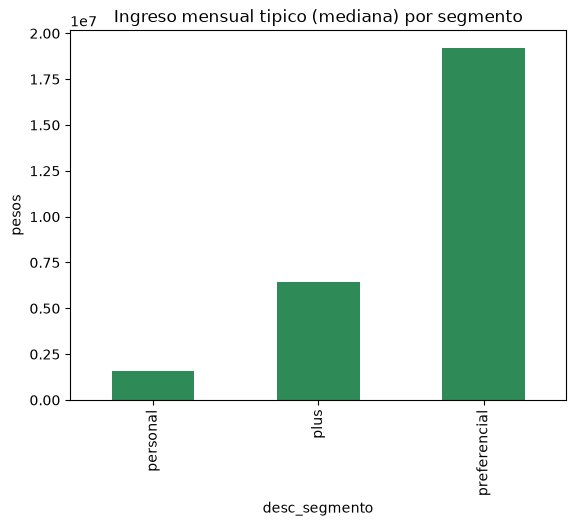

In [8]:
resumen_por_segmento['ingresos_mensuales'].plot(
    kind='bar', title='Ingreso mensual tipico (mediana) por segmento', color='seagreen'
)
plt.ylabel('pesos')
plt.show()

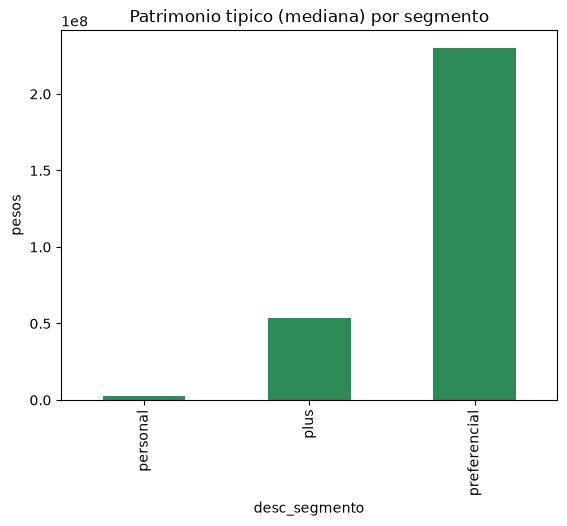

In [9]:
resumen_por_segmento['total_patrimonio'].plot(
    kind='bar', title='Patrimonio tipico (mediana) por segmento', color='seagreen'
)
plt.ylabel('pesos')
plt.show()

**Lectura:** si el patrimonio típico sube claramente de Personal a Plus a Preferencial,
confirma algo esperable: el segmento comercial que ya usa el banco es un buen resumen de
capacidad económica — una variable simple y disponible que probablemente sea útil para el
modelo de propensión y de monto potencial.

## 4. ¿Quién ya usa algún producto de inversión hoy?

Igual que en el notebook 00, pero esta vez sobre la tabla ya integrada y limpia, y de
forma visual: dividimos a los clientes en tres grupos según qué productos tienen.

In [10]:
tiene_inversion = (
    cliente_360['tiene_fiducuenta'] |
    cliente_360['tiene_cdt_inv_virtual'] |
    cliente_360['tiene_invesbot']
)
tiene_transaccional = (
    cliente_360['tiene_aho_cte'] |
    cliente_360['tiene_bolsillos']
)

def clasificar(fila_tiene_inversion, fila_tiene_transaccional):
    if fila_tiene_inversion:
        return 'Ya invierte'
    elif fila_tiene_transaccional:
        return 'Solo transaccional'
    else:
        return 'Sin senal en la muestra'

cliente_360['grupo_producto'] = [
    clasificar(inv, trans) for inv, trans in zip(tiene_inversion, tiene_transaccional)
]

cliente_360['grupo_producto'].value_counts()

grupo_producto
Sin senal en la muestra    329313
Solo transaccional         310092
Ya invierte                220391
Name: count, dtype: int64

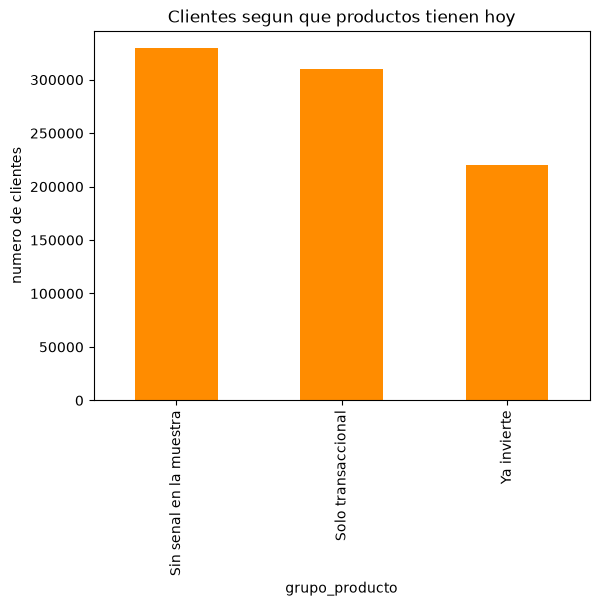

In [11]:
cliente_360['grupo_producto'].value_counts().plot(
    kind='bar', title='Clientes segun que productos tienen hoy', color='darkorange'
)
plt.ylabel('numero de clientes')
plt.show()

**Lectura de negocio:** "Ya invierte" son los candidatos más obvios para migrar/cross-sell
a la nueva App. "Solo transaccional" es la oportunidad de activación más grande (tienen
relación con el banco y liquidez, pero ningún producto de inversión). "Sin señal en la
muestra" se documentó como supuesto en el notebook 00 — no se puede confirmar si
realmente no tienen producto o si no salieron en la muestra entregada.

## 5. El caso de Invesbot: el perfil que más se parece a la nueva App

Recordemos por qué importa: Invesbot es el producto más parecido a la nueva App de
inversiones (servicio digital con recomendaciones automatizadas). Si su perfil de
adopción tiene sentido de negocio, respalda usarlo como referencia para el modelo de
propensión (notebook 03).

In [12]:
comparacion_invesbot = cliente_360.groupby('tiene_invesbot')[
    ['ingresos_mensuales', 'total_patrimonio']
].median()
comparacion_invesbot.index = ['No tiene Invesbot', 'Tiene Invesbot']
comparacion_invesbot

,ingresos_mensuales,total_patrimonio
No tiene Invesbot,"2,000,000.00","6,908,000.00"
Tiene Invesbot,"6,526,146.00","65,256,700.00"


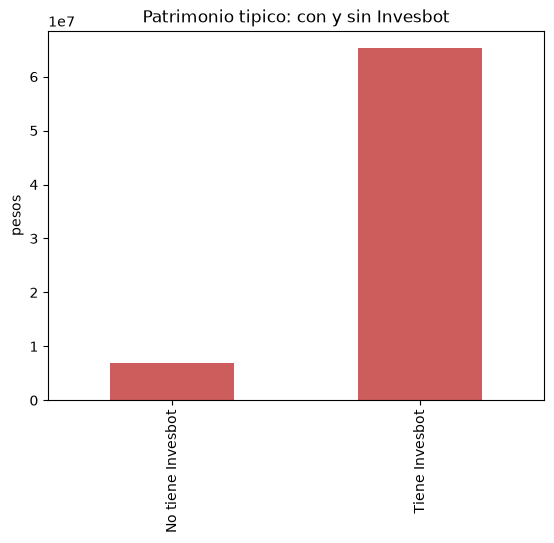

In [13]:
comparacion_invesbot['total_patrimonio'].plot(
    kind='bar', title='Patrimonio tipico: con y sin Invesbot', color='indianred'
)
plt.ylabel('pesos')
plt.show()

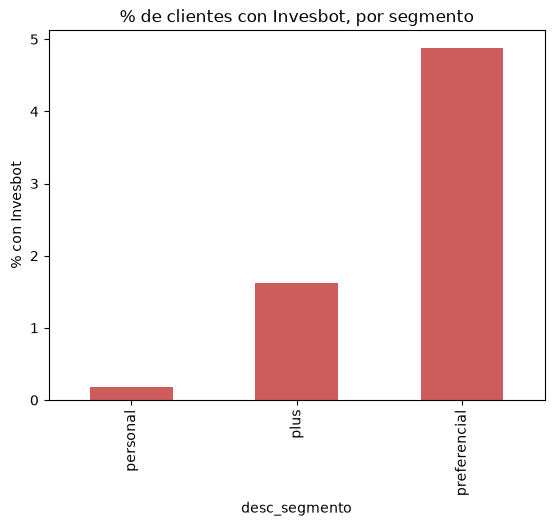

In [14]:
tasa_adopcion_segmento = cliente_360.groupby('desc_segmento')['tiene_invesbot'].mean() * 100
tasa_adopcion_segmento.plot(
    kind='bar', title='% de clientes con Invesbot, por segmento', color='indianred'
)
plt.ylabel('% con Invesbot')
plt.show()

**Lectura:** la diferencia de patrimonio entre quien tiene Invesbot y quien no, y el hecho
de que la adopción suba claramente con el segmento comercial, confirma que hay una señal
real de negocio detrás — no es ruido. Esto respalda la decisión (tomada junto con el
notebook 00) de usar "tiene Invesbot" como variable objetivo aproximada para el modelo de
propensión.

## 6. Resumen de hallazgos para el negocio

- La base es mayoritariamente segmento Personal en volumen, pero el patrimonio típico
  crece fuerte hacia Plus y Preferencial — el segmento comercial es una variable simple y
  útil para entender capacidad de inversión.
- Solo el 25.6% de los clientes ya tiene algún producto de inversión — el 36.1% que es
  "solo transaccional" es la oportunidad de activación más grande para la nueva App.
- El perfil de quien ya tiene Invesbot (mayor ingreso, mayor patrimonio, mayor
  representación en segmentos altos) confirma que hay una señal real y aprovechable para
  construir el modelo de propensión del siguiente notebook.